In [ ]:
import pandas as pd
import seaborn as sns
from datetime import datetime
from datetime import date

In [ ]:
# Текущая дата и время
now = datetime.now()
print(now)

2025-06-26 05:44:45.906133


In [ ]:
# Создание даты и времени вручную
dt = datetime(2024, 2, 26, 15, 30)
print(dt)

2024-02-26 15:30:00


In [ ]:
d = date(2024, 2, 26)
print(d)


2024-02-26


In [ ]:
from datetime import time

t = time(15, 30, 45)
print(t)


15:30:45


In [ ]:
from datetime import timedelta

delta = timedelta(days=10, hours=5)
print(delta)  # 10 days, 5:00:00

new_date = dt + delta
print(dt)
print(new_date)


10 days, 5:00:00
2024-02-26 15:30:00
2024-03-07 20:30:00


$$
\begin{array}{|c|l|c|}
    \hline
    \textbf{Код} & \textbf{Значение} & \textbf{Пример} \\
    \hline
    \%Y & \text{Год (4 цифры)} & 2025 \\
    \%y & \text{Год (2 последние цифры)} & 25 \\
    \%m & \text{Месяц (с нулем)} & 02 \\
    \%d & \text{День (с нулем)} & 26 \\
    \%H & \text{Часы (24-часовой формат)} & 14 \\
    \%M & \text{Минуты} & 30 \\
    \%S & \text{Секунды} & 15 \\
    \hline
\end{array}
$$


In [ ]:
from datetime import datetime

# Текущая дата и время
now = datetime.now()

# Форматирование в строку
formatted = now.strftime("%d-%B-%Y %H:%M:%S")
print(formatted)  # Пример: 2025-02-26 14:30:15


26-June-2025 05:46:25


In [ ]:
type(formatted)

str

In [ ]:
type(now)

datetime.datetime

In [ ]:
now

datetime.datetime(2025, 6, 25, 22, 33, 10, 802024)

# Работа с датой в датафреймах


In [ ]:
df = pd.DataFrame({
    "date": ["2024-02-26", "2025-02-26"]
})

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2 non-null      object
dtypes: object(1)
memory usage: 148.0+ bytes


In [ ]:
# Преобразуем в datetime
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2 non-null      datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 148.0 bytes


In [ ]:
# Извлекаем год, месяц, день, день недели
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["weekday"] = df["date"].dt.day_name()

df

,date,year,month,day,weekday
0,2024-02-26,2024,2,26,Monday
1,2025-02-26,2025,2,26,Wednesday


| Код  | Значение                  | Пример    |
|------|---------------------------|-----------|
| `%Y` | Год (4 цифры)             | `2025`    |
| `%y` | Год (2 последние цифры)   | `25`      |
| `%m` | Месяц (с нулем)           | `02`      |
| `%d` | День (с нулем)            | `26`      |
| `%H` | Часы (24-часовой формат)  | `14`      |
| `%M` | Минуты                    | `30`      |
| `%S` | Секунды                   | `15`      |
| `%B` | Полное название месяца     | February

In [ ]:
# Форматируем в строку
df["formatted_date"] = df["date"].dt.strftime("%d %B %Y")

df


,date,year,month,day,weekday,formatted_date
0,2024-02-26,2024,2,26,Monday,26 February 2024
1,2025-02-26,2025,2,26,Wednesday,26 February 2025


<font color='green'>**Работа с временными интервалами**

1) pd.Timedelta(days=10) - Работает с фиксированными единицами времени (дни, часы, минуты, секунды и т. д.).


2) pd.DateOffset(months=1) - Учитывает календарные правила (разное количество дней в месяцах, високосные годы и т. д.), months=1 означает "следующий месяц", а не фиксированное количество дней, подходит для операций, где важна календарная логика (например, "предыдущий месяц").

In [ ]:
df["date_plus_10_days"] = df["date"] + pd.Timedelta(days=10)
df["date_minus_1_month"] = df["date"] - pd.DateOffset(months=1)



In [ ]:
df

,date,year,month,day,weekday,formatted_date,date_plus_10_days,date_minus_1_month
0,2024-02-26,2024,2,26,Monday,26 February 2024,2024-03-07,2024-01-26
1,2025-02-26,2025,2,26,Wednesday,26 February 2025,2025-03-08,2025-01-26


<font color='green'>**Фильтрация по дате**

In [ ]:
df = df[df["date"] > "2024-06-01"]
df

,date,year,month,day,weekday,formatted_date,date_plus_10_days,date_minus_1_month
1,2025-02-26,2025,2,26,Wednesday,26 February 2025,2025-03-08,2025-01-26


<font color='green'>**Генерация временного ряда**

In [ ]:
date_range = pd.date_range(start="2024-01-01", periods=10, freq="D")
date_range


DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
# Загружаем данные

df = sns.load_dataset('flights')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        144 non-null    int64   
 1   month       144 non-null    category
 2   passengers  144 non-null    int64   
dtypes: category(1), int64(2)
memory usage: 2.9 KB


In [ ]:
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [ ]:
df[['year', 'month']] = df[['year', 'month']].astype('str')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        144 non-null    object
 1   month       144 non-null    object
 2   passengers  144 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 3.5+ KB


In [ ]:
df['date'] = df['year'] + "-" + df["month"]

In [ ]:
df

,year,month,passengers,date
0,1949,Jan,112,1949-Jan
1,1949,Feb,118,1949-Feb
2,1949,Mar,132,1949-Mar
3,1949,Apr,129,1949-Apr
4,1949,May,121,1949-May
...,...,...,...,...
139,1960,Aug,606,1960-Aug
140,1960,Sep,508,1960-Sep
141,1960,Oct,461,1960-Oct
142,1960,Nov,390,1960-Nov


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   year        144 non-null    object
 1   month       144 non-null    object
 2   passengers  144 non-null    int64 
 3   date        144 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.6+ KB


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.head()

/tmp/ipython-input-47-2227006722.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


,year,month,passengers,date
0,1949,Jan,112,1949-01-01
1,1949,Feb,118,1949-02-01
2,1949,Mar,132,1949-03-01
3,1949,Apr,129,1949-04-01
4,1949,May,121,1949-05-01


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   year        144 non-null    object        
 1   month       144 non-null    object        
 2   passengers  144 non-null    int64         
 3   date        144 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 4.6+ KB


In [ ]:
df = df.set_index(df.date)
df.head()

,year,month,passengers,date
date,,,,
1949-01-01,1949,Jan,112,1949-01-01
1949-02-01,1949,Feb,118,1949-02-01
1949-03-01,1949,Mar,132,1949-03-01
1949-04-01,1949,Apr,129,1949-04-01
1949-05-01,1949,May,121,1949-05-01


In [ ]:
df = df.drop(columns=['year', 'month', 'date'])
df.head()

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
type(df)

pandas.core.frame.DataFrame

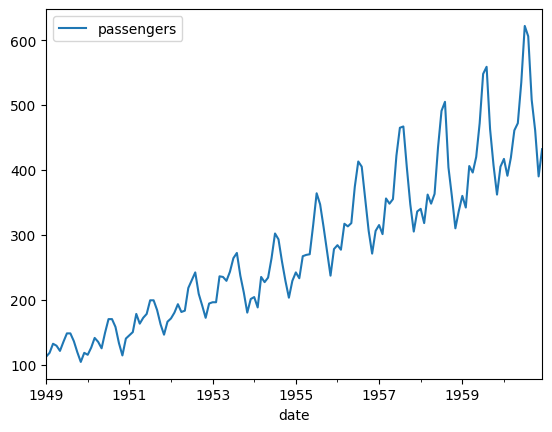

In [ ]:
_ = df.plot()

### Преимущества индекстов в виде datetime

* срезы по датам, годам, месяцам...
* вместо group_by == resample

In [ ]:
df.index.weekday

Index([5, 1, 1, 4, 6, 2, 4, 0, 3, 5,
       ...
       1, 4, 6, 2, 4, 0, 3, 5, 1, 3],
      dtype='int32', name='date', length=144)

In [ ]:
df['weekday'] = df.index.weekday

In [ ]:
df

,passengers,weekday
date,,
1949-01-01,112,5
1949-02-01,118,1
1949-03-01,132,1
1949-04-01,129,4
1949-05-01,121,6
...,...,...
1960-08-01,606,0
1960-09-01,508,3
1960-10-01,461,5


In [ ]:
df['1949':'1950']

,passengers,weekday
date,,
1949-01-01,112,5
1949-02-01,118,1
1949-03-01,132,1
1949-04-01,129,4
1949-05-01,121,6
1949-06-01,135,2
1949-07-01,148,4
1949-08-01,148,0
1949-09-01,136,3


In [ ]:
df['1949-06':'1950-6']

,passengers,weekday
date,,
1949-06-01,135,2
1949-07-01,148,4
1949-08-01,148,0
1949-09-01,136,3
1949-10-01,119,5
1949-11-01,104,1
1949-12-01,118,3
1950-01-01,115,6
1950-02-01,126,2


In [ ]:
df.resample('M').sum()

/tmp/ipython-input-58-3731312487.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M').sum()


,passengers,weekday
date,,
1949-01-31,112,5
1949-02-28,118,1
1949-03-31,132,1
1949-04-30,129,4
1949-05-31,121,6
...,...,...
1960-08-31,606,0
1960-09-30,508,3
1960-10-31,461,5


In [ ]:
df.resample('YE').sum()

,passengers,weekday
date,,
1949-12-31,1520,35
1950-12-31,1676,40
1951-12-31,2042,38
1952-12-31,2364,32
1953-12-31,2700,39
1954-12-31,2867,30
1955-12-31,3408,35
1956-12-31,3939,43
1957-12-31,4421,36


In [ ]:
df.drop(columns='weekday', inplace=True)

## Rolling window

* скользящее окно,


In [ ]:
df = df[['passengers']].copy()

In [ ]:
df['rolling_window_2'] = df['passengers'].rolling(window=2).mean()

In [ ]:
df['rolling_window_3'] = df['passengers'].rolling(window=3).mean()

In [ ]:
(112+118)/2

115.0

In [ ]:
(112+118+132)/3

120.66666666666667

In [ ]:
df

,passengers,rolling_window_2,rolling_window_3
date,,,
1949-01-01,112,NaN,NaN
1949-02-01,118,115.0,NaN
1949-03-01,132,125.0,120.666667
1949-04-01,129,130.5,126.333333
1949-05-01,121,125.0,127.333333
...,...,...,...
1960-08-01,606,614.0,587.666667
1960-09-01,508,557.0,578.666667
1960-10-01,461,484.5,525.000000


In [ ]:
# Полезно уметь делать датасет с диапазоном дат без данных

In [ ]:
pd.date_range('1961-01-01', '1962-12', freq='MS')

DatetimeIndex(['1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01',
               '1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01', '1962-11-01', '1962-12-01'],
              dtype='datetime64[ns]', freq='MS')

## Сдвиг и производная от графика

In [ ]:
df['passengers']

,passengers
date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
df['passengers'].shift(1).head() # по умолчанию сдвиг 1, можно брать отрицательные значения

,passengers
date,
1949-01-01,NaN
1949-02-01,112.0
1949-03-01,118.0
1949-04-01,132.0
1949-05-01,129.0


In [ ]:
df['passengers_shift_1'] = df['passengers'].shift(1)

In [ ]:
df['passengers_shift_minus_1'] = df['passengers'].shift(-1)

In [ ]:
df['passengers_shift_2'] = df['passengers'].shift(2)

In [ ]:
df['passengers_shift_12'] = df['passengers'].shift(12)

In [ ]:
df.head(14)

,passengers,passengers_shift_1,passengers_shift_2,passengers_shift_12,passengers_shift_minus_1
date,,,,,
1949-01-01,112,NaN,NaN,NaN,118.0
1949-02-01,118,112.0,NaN,NaN,132.0
1949-03-01,132,118.0,112.0,NaN,129.0
1949-04-01,129,132.0,118.0,NaN,121.0
1949-05-01,121,129.0,132.0,NaN,135.0
1949-06-01,135,121.0,129.0,NaN,148.0
1949-07-01,148,135.0,121.0,NaN,148.0
1949-08-01,148,148.0,135.0,NaN,136.0
1949-09-01,136,148.0,148.0,NaN,119.0
